In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.metrics import  confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc,classification_report
import matplotlib.pyplot as plt
import matplotlib 
import numpy as np
import os
from os import path
     

In [6]:
#loading data
Data_path = r"D:\BTS\2DAI\PFE\Projects\PFE__Model"
X_test = np.load(path.join(Data_path, 'testX.npy'))
Y_test = np.load(path.join(Data_path, 'testY.npy'))

In [7]:
#loading the model
model=load_model(path.join(Data_path,'X-rays_best_model.h5'))


In [8]:
model.evaluate(X_test,Y_test)

19/19 [==============================] - 43s 2s/step - loss: 0.0626 - acc: 0.9833


[0.06256905943155289, 0.9833333492279053]

In [9]:
#Probabilities 
modelProb = model.predict(X_test, batch_size=16)
#index for the probabilities
modelProb = np.argmax(modelProb, axis=1)


38/38 [==============================] - 48s 1s/step


In [12]:
print(classification_report(Y_test.argmax(axis=1),modelProb,target_names=['Covid-19','Normal','Pneumonia']))
     

              precision    recall  f1-score   support

    Covid-19       0.98      0.97      0.97       200
      Normal       0.98      0.98      0.98       200
   Pneumonia       0.99      1.00      1.00       200

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



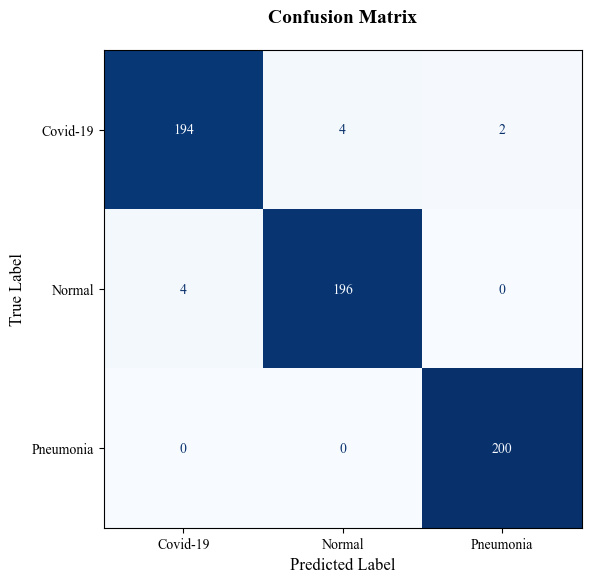

<Figure size 640x480 with 0 Axes>

In [13]:
y_true = np.argmax(Y_test, axis=1)
# 1. Config dial l-khet (Style GitHub / Scientific)
plt.rcParams["font.family"] = "Times New Roman"

# 2. N-9addou l-data
y_true = np.argmax(Y_test, axis=1)
y_pred = modelProb 

cm = confusion_matrix(y_true, y_pred)
class_names = ['Covid-19', 'Normal', 'Pneumonia']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))


disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) 

# 5. N-zidou l-3anawin
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.tight_layout()

plt.show()
plt.savefig('matrice_X-rayx-Model',)

In [14]:
print(Y_test[0])
predIdxs = model.predict(X_test, batch_size=16)
print(predIdxs[0])

[1 0 0]
38/38 [==============================] - 39s 1s/step
[9.9896073e-01 1.0298844e-03 9.3953586e-06]
